# Lab Assignment: Generative AI

#### Lab team: teamCode

##### Name (member 1): Lucas Miranda López

##### Name (member 2): Iván Dominguez Hernández

* Please include your full name at the beginning of all submitted files.
* Make sure the presentation is well-structured: the report will be evaluated not only for correctness, but also for clarity, conciseness, and completeness.
* Make use of figures and tables to summarize the results and illustrate the discussions.
* If external material is used, the sources must be cited. 
* Include references in APA format https://pitt.libguides.com/citationhelp/apa7. Lack or poorly formatted references can be penalized.
* A generative AI tool can be used for consultation. You must specify the tool used in your report.
* You are not allowed to use a generative AI tool to generate code.

Submit a single `.zip` file, whose name has the format `AA3_2024_2025_P02_teamCode_lastName1_lastName2.zip` 
The name must not include graphical accents, spaces, uppercase letters, or special characters.

For example: `AA3_2024_2025_P02_V03_munyoz_deLaRosa.zip`

This compressed file must include the following files:

* This Python notebook with the solutions of the exercises. The notebook should include only code snippets, figures, tables, derviations and explanations (with LaTex if necessary) in Markdown cells. Handwritten material can be included in the Python notebook as images. Functions should be defined in a separate `.py` file, not in the notebook.
* The necessary `.py` and addional files to ensure the Python notebook code can be executed sequentially without errors.
* A PDF file generated from the notebook (Export the notebook as an HTML file. Open the HTML file in a Browser and print it as a PDF file). 

Make sure that all the code cells can be executed squentially without errors (Kernel -> Restart & Run All). Exectution and formatting errors will be penalized.

The grade of this lab assignment is based on
* This submission (50 %).
* An individual in-class exam (50%).


Evaluation criteria:
* [6 points] Quality of the report (correctness, clarity, conciseness, completeness).
* [3 points] Quality of the code (correctness, adherence to a Python style guide -for instance, Google's-, comments, functional decomposition).
* [1 point]  References.                                                                   

## References:

1. Song, Y., Sohl-Dickstein, J., Kingma, D. P., Kumar, A., Ermon, S., and Poole, B. (2021). Score-based generative modeling through stochastic differential equations. *International Conference on Learning Representations*. https://arxiv.org/abs/2011.13456

2. Anderson, B. D. O. (1982). Reverse-time diffusion equation models. *Stochastic Processes and their Applications*, 12(3), 313–326.

3. Hyvärinen, A. (2005). Estimation of non-normalized statistical models by score matching. *Journal of Machine Learning Research*, 6(24), 695–709.

4. Vincent, P. (2010). A connection between score matching and denoising autoencoders. Tech. Rep. 1358, Department of Computer Science and Operations Research, University of Montreal.

5. Chen, R. T. Q., Rubanova, Y., Bettencourt, J., and Duvenaud, D. K. (2018). Neural ordinary differential equations. *Advances in Neural Information Processing Systems*, vol. 31.

6. Heusel, M., Ramsauer, H., Unterthiner, B., Nessler, B., and Hochreiter, S. (2017). GANs trained by a two time-scale update rule converge to a local Nash equilibrium. *Advances in Neural Information Processing Systems*, vol. 30.

7. Theis, L., van den Oord, A., and Bethge, M. (2015). A note on the evaluation of generative models. arXiv preprint.

8. Øksendal, B. (2003). *Stochastic Differential Equations: An Introduction with Applications* (6th ed.). Springer.

9. Risken, H. (1989). *The Fokker–Planck Equation: Methods of Solution and Applications* (2nd ed.). Springer.

10. Nichol, A. Q., and Dhariwal, P. (2021). Improved denoising diffusion probabilistic models. *Proceedings of the 38th International Conference on Machine Learning*, PMLR 139, 8162–8171.

11. Netzer, Y., Wang, T., Coates, A., Bissacco, A., Wu, B., and Ng, A. Y. (2011). Reading digits in natural images with unsupervised feature learning. *NIPS Workshop on Deep Learning and Unsupervised Feature Learning*.

12. Ho, J., Jain, A., and Abbeel, P. (2020). Denoising diffusion probabilistic models. *Advances in Neural Information Processing Systems*, vol. 33, 6840–6851.

13. Ho, J., and Salimans, T. (2022). Classifier-free diffusion guidance. arXiv:2207.12598.

14. Lugmayr, A., Danelljan, M., Romero, A., Yu, F., Timofte, R., and Van Gool, L. (2022). RePaint: Inpainting using denoising diffusion probabilistic models. *CVPR*, 11461–11471.

*Note: this project uses Claude Sonnet 4.5 (Anthropic) as a generative AI consultation tool, in accordance with the assignment guidelines.*

## Exercise 1:  Generative AI based on diffusion models: Brownian motion 

In this exercise the training data is generated by injectiong noise using Brownian motion (variance exploding diffusion model).
The stochastic differencial equation (SDE) that characterizes this forward diffusion process is
$$
d\mathbf{x}(t) = \sigma^t d\mathbf{W}(t) 
$$

with $\mathbf{x}(0) \sim p_0\left(\mathbf{x} \right)$, and $\sigma > 0$.
1. What is the distribution of $\mathbf{x}(t)$ assuming that $\mathbf{x}(0) = \mathbf{x}_0$ for arbitrary t?
  
   Since there is no drift term we only need to integrate the diffusion by the general formal solution of an SDE with Itô's form given the initial condition.
   $$
   \mathbf{x}(t) = \mathbf{x}_0 + \int_0^t \sigma^{s} dW(s)
   $$

   We know the Itô's solution follows a gaussian with $\mu = \mathbf{x}_0$ but we need to calculate $\sigma^2(t)$ which in our case is:
$$
\sigma^2(t) = \int_0^t g^2(s)ds = \int_0^t \sigma^{2s} ds = \frac{\sigma^{2t} - 1}{2log\sigma}
$$

Finally we get: $$\mathbf{x}(t) \sim \mathcal{N}\!\left(\mathbf{x}_0,\ \frac{\sigma^{2t}-1}{2\ln\sigma}\,\mathbf{I}\right)$$

Note: An alternative approach is given by Song (2021) as referenced in our memory and is such as:

$$ \sigma^2(t) = \sigma_{\text{min}}(\frac{\sigma_{\text{max}}}{\sigma_{\text{min}}})^t \approx \sigma^{2t}$$

In this case we determine $\sigma$ by an heuristic manner that depends on the dataset

1. What is the SDE for the time-reversed process? 
   $$d\textbf{x} = -\sigma^{2t}\nabla_\textbf{x}\operatorname{log}p_t(\textbf{x})dt + \sigma^t dW$$
2. For the synthesis of new images
    1. In what interval is the reverse process SDE integrated?
    
    We need to integrate from the furthest moment of the forward process, in this case $ t=T$ until the original moment $ t=0$
    $$
    t \in [T, 0]
    $$
    2. From which distribution $\pi\left(\mathbf{x} \right)$ is the initial condition of the reverse SDE sampled?
    
    Note that we are in the reversed process so $ x(T) = x_T$ and this is sampled from this distribution:

$$\mathbf{x}(T) \sim \mathcal{N}\!\left(\mathbf{0},\ \frac{\sigma^{2T}-1}{2\ln\sigma}\,\mathbf{I}\right)$$

> **References:** Forward SDE and marginal distribution: Song et al. (2021) [Ref. 1]. Itô integration and SDE solution: Øksendal (2003) [Ref. 8]. Reverse-time SDE: Anderson (1982) [Ref. 2].

### Exercise 1.1:  Training the model by weighted sum of denoising score matching objectives
1. Give the mathematical form and explain the cost function used in the training of the generative AI model.
$$ \ell(\boldsymbol{\theta}) = \frac{1}{N} \sum_{n=1}^N \left\| \sigma(t_n) \, s_{\theta}(\mathbf{x}(t_n), t_n) + \mathbf{z}_n\right\|_2^2
$$
This function is an evolution of the cost function stated by Hyvärinen (2005) [Ref. 3] and further conclusions from Vincent (2010) [Ref. 4],  rewritten by Song et al. (2021) [Ref. 1] focused on noise detection. (note here we use loss/cost function indistinguishably). 

What this fucntion means intuintively is that our $ s_{\theta}(\mathbf{x}(t_n), t_n)$ in practice implemented as  U-net is going to try to predict the noise that we have previously injected at each corruption step. We achieve this because we know that $\nabla_{\mathbf{x}} \log p_{0t}\!\left(\mathbf{x}(t_n)\mid\mathbf{x}_0\right) = -\frac{\mathbf{z}_n}{\sigma(t_n)}$ and our prediction is $ s_{\theta}(\mathbf{x}(t_n), t_n) \approx \nabla_{\mathbf{x}} \log p_t(\mathbf{x}(t_n))$ so we are essentially calculating with the norm $ L_2$ the distance between the predicted score $ s_{\theta}$ and the true score $-\frac{\mathbf{z}_n}{\sigma(t_n)}$, which is known during training because we injected $\mathbf{z}_n$
ourselves.

2. Indicate what type of neural network is used to model the score, its inputs, outputs, and architecture.   

To model the score we use a **U-net** (Song et al., 2021 [Ref. 1]; adapted architecture)

**Inputs**:
- The image we have introduced noise to in our case $\mathbf{x}(t) \in \mathbb{R}^{64 \times 64 \times C}$ at corruption level $ t$
- Time "t"

**Output**:
- The estimated score $ s_{\theta}(\mathbf{x}(t), t) \in \mathbb{R}^{64 \times 64 \times C}$, 

**Architecture**:
- **Encoder**:Downsamples the resolution by convolutional blocks and max-pooling, incrementing the depth of the channels at each level
- **Decoder**: Recovers the original resolution by transposed convolutions
- **Skip-connections**: Connects the charateristic maps of each level of the encoder to the decoder

3. Explain how time is input in the neural network model for the time-dependent score function using random Fourier features.

Since $ t \in \mathbb{R}$ is a scalar, it cannot be passed directly into a convolutional network without losing expressive power. Instead, $ t$ is lifted to a high-dimensional embedding via Random Fourier Features (RFF):

$$
\gamma(t) = \left[\sin(2\pi\,\omega_1 t),\;\cos(2\pi\,\omega_1 t),\;\ldots,\;\sin(2\pi\,\omega_{d/2}\,t),\;\cos(2\pi\,\omega_{d/2}\,t)\right] \in \mathbb{R}^d
$$

where the frequencies $\omega_i \sim \mathcal{N}(0, s^2)$ are fixed at initialization. The resulting vector is then passed through a trainable linear layer to produce the final embedding $\mathbf{e}(t) \in \mathbb{R}^{d_{\text{emb}}}$.

This embedding is injected at every resolution of the U-Net by adding a bias:

$$
h_\ell \;\leftarrow\; h_\ell + W_\ell\,\mathbf{e}(t)
$$

where $ W_\ell$ is a learned projection for each level $\ell$. The sinusoidal basis ensures that nearby time values produce smoothly varying embeddings, while the random frequencies give the model the capacity to distinguish fine-grained noise levels across the full range $ t \in [0, T]$(Song et al., 2021 [Ref. 1]).

4. Illustrate how to train a model to generate handwritten digits for the MNIST dataset using the Brownian motion diffusion model.
This first block of code should run in less than 5 minutes.

> **References:** Weighted denoising score-matching loss: Song et al. (2021) [Ref. 1]. Score matching objective: Hyvärinen (2005) [Ref. 3]. Connection to denoising autoencoders: Vincent (2010) [Ref. 4]. U-Net score architecture: Song et al. (2021) [Ref. 1].

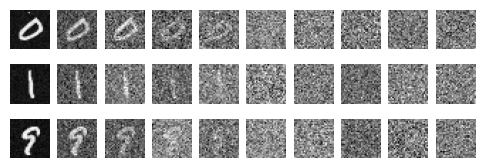

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from diffusion_lib import VEProcess
from diffusion_lib.utils.visualization import plot_image_evolution

# 1. Cargar unas imágenes MNIST limpias
dataset = datasets.MNIST(root='data', train=True, download=True,
                         transform=transforms.ToTensor())
loader  = DataLoader(dataset, batch_size=64, shuffle=True)
x_0, _  = next(iter(loader))        # [B, 1, 28, 28]
n_images = 3
x_0 = x_0[:n_images]

# 2. El mismo proceso forward que usaste al entrenar
ve = VEProcess(sigma=25.0)

# 3. Elegir tiempos. Para VE con sigma=25 conviene espaciado log-ish,
#    porque la varianza crece exponencialmente con t.
times = torch.tensor([1e-3, 0.05, 0.10, 0.20, 0.30,
                      0.50, 0.70, 0.85, 0.95, 1.00])

# 4. Aplicar el kernel cerrado p(x_t | x_0) a cada t y apilar en el formato
#    que pide plot_image_evolution: (n_images, C, H, W, n_steps)
trajectory = []
for t in times:
    t_batch = t.expand(n_images)
    x_t, _  = ve.perturb(x_0, t_batch)     # (n_images, 1, 28, 28)
    trajectory.append(x_t)
images_t = torch.stack(trajectory, dim=-1)  # (n_images, 1, 28, 28, len(times))

# 5. Mismo plot que en el demo
_ = plot_image_evolution(
    images=images_t,
    n_images=n_images,
    n_intermediate_steps=list(range(len(times))),  # los 10 a la vez
    figsize=(6, 2),
)

### Exercise 1.2: Generation using the Euler-Maruyama integrator
Use a model that you have previously trained (not the one in the previous exercise) high-quality model to generate some samples using the Euler-Maruyama integrator.

In [2]:
import torch
from diffusion_lib import UNetScoreModelColor as ScoreNetColor
from diffusion_lib import VEProcess, EulerMaruyamaSampler, GenerativeDiffusionModel

device = torch.device('cpu')


ve_process = VEProcess(sigma=25.0)
score_model = ScoreNetColor(marginal_prob_std=ve_process.sigma_t)

n_epochs = 500
checkpoint = torch.load(
    f'other_checkpoints/digit_6_{n_epochs}_epochs.pth',
    map_location=device,
    weights_only=True,
)
score_model.load_state_dict(checkpoint)

gm = GenerativeDiffusionModel(ve_process, EulerMaruyamaSampler(), score_model, device)

n_images = 5
synthetic_images_t = gm.sample(
    n_images=n_images,
    img_shape=(3, 32, 32),
    n_steps=500,
    return_trajectory=True,
)

print(f"Dimensiones finales: {synthetic_images_t.shape}")

Dimensiones finales: torch.Size([5, 3, 32, 32, 501])


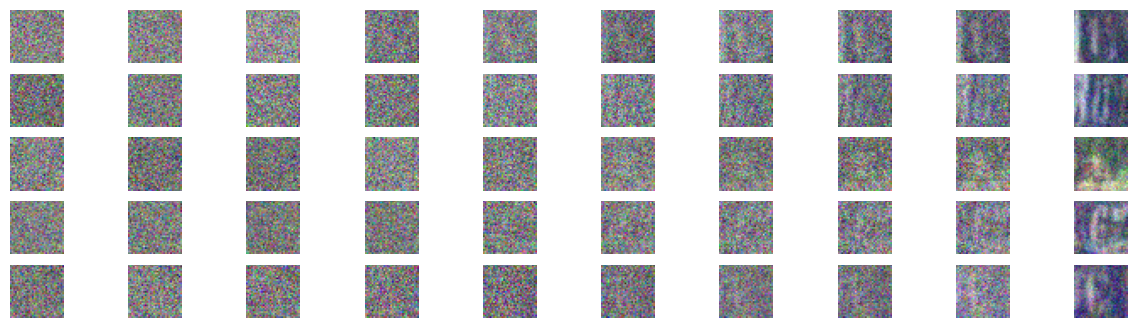

In [3]:
from diffusion_lib.utils.visualization import plot_image_evolution_rgb

_ = plot_image_evolution_rgb(
    
    images=synthetic_images_t,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

### Exercise 1.3: Generation using a probability flow ODE.
1. Explain what is the Fokker-Planck equation and in what way is it related to an SDE.

The Fokker-Planck equation (also known as the Kolmogorov forward equation) is a partial differential equation that describes how the probability density function $ p_t(\mathbf{x})$ of a system evolves over time when the system is subject to both deterministic drift and random stochastic noise.

$$    
    dX_t = \left[
        -\frac{\beta(t)}{2}\,X_t
        - \beta(t)\,\nabla_{x}\log p_t(X_t)
    \right]dt
    + \sqrt{\beta(t)}\,d\bar{W}_t
$$

The relation to the SDE relies on the fact that for any SDE, exists a strictly deterministic ODE expressed by an algebraic rearrange of the SDE expressed in the Fokker-Planck form.

2. Explain how the probability flow ODE can be used to generate samples from $ p_0\left(\mathbf{x} \right)$.

The probability flow ODE shares the same marginals $ p_t(\mathbf{x})$ as the forward SDE but is fully deterministic:
$$
\frac{d\mathbf{x}}{dt} = f(\mathbf{x},t) - \frac{1}{2}g(t)^2\,\nabla_{\mathbf{x}}\log p_t(\mathbf{x})
$$
Replacing the score by $ s_\theta(\mathbf{x},t)$, generation reduces to:

- Sample $$\mathbf{x}(T)\sim\mathcal{N}(\mathbf{0},\sigma^2(T)\mathbf{I})$$.

- Integrate backwards $ t:T\to 0$ with Euler steps:
    $$\mathbf{x}{n+1}=\mathbf{x}_n+\!\left[f(\mathbf{x}_n,t_n)-\tfrac{1}{2}g(t_n)^2\,s\theta(\mathbf{x}_n,t_n)\right]\Delta t,\quad \Delta t<0$$
    
- Return $$\mathbf{x}(0)\sim p_0(\mathbf{x})$$



3. Implement and illustrate the use of this method to generate synthetic images of handwritten digits.

> **References:** Fokker-Planck equation: Risken (1989) [Ref. 9]. Relation between SDE and Fokker-Planck: Øksendal (2003) [Ref. 8]. Probability flow ODE and sample generation: Song et al. (2021) [Ref. 1].

In [4]:
import torch
from diffusion_lib import UNetScoreModelColor as ScoreNetColor
from diffusion_lib import VEProcess, ProbabilityFlowODESampler, GenerativeDiffusionModel

device = torch.device('cpu')

ve_process = VEProcess(sigma=25.0)
score_model = ScoreNetColor(marginal_prob_std=ve_process.sigma_t)

checkpoint = torch.load(
    'other_checkpoints/digit_6_500_epochs.pth',
    map_location=device,
    weights_only=True,
)
score_model.load_state_dict(checkpoint)
print("Modelo cargado.")


gm_ode = GenerativeDiffusionModel(ve_process, ProbabilityFlowODESampler(), score_model, device)

n_images = 5
trajectory = gm_ode.sample(
    n_images=n_images,
    img_shape=(3, 32, 32),
    n_steps=500,
    return_trajectory=True,
)

print(f"Trayectoria ODE: {trajectory.shape}")

Modelo cargado.
Trayectoria ODE: torch.Size([5, 3, 32, 32, 501])


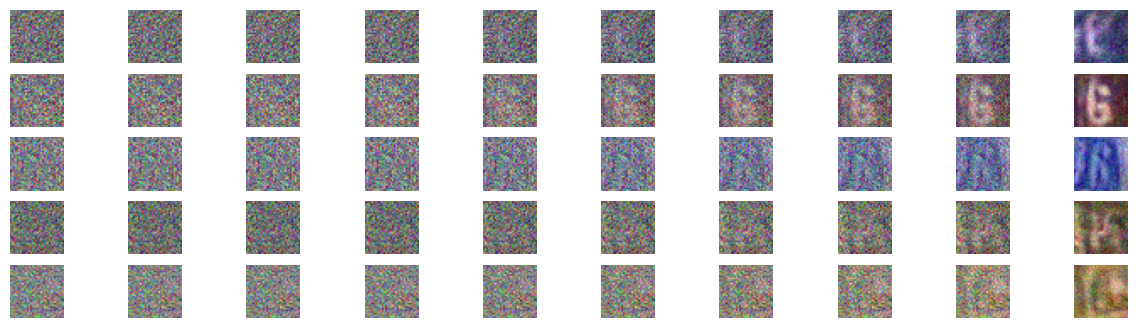

In [5]:
from diffusion_lib.utils.visualization import plot_image_evolution_rgb

_ = plot_image_evolution_rgb(
    images=trajectory,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

4. Indicate how to use this scheme to compute likelihoods. Implement this functionality and illustrate its use.
The probability flow ODE associated with the forward SDE $ dx = f(x,t)\,dt + g(t)\,dW$ is:

$$dx = {\left[f(x,t) - \tfrac{1}{2}g(t)^2\,\nabla_x \log p_t(x)\right]},dt$$

Because this ODE shares the same marginal densities $\{p_t\}$ as the original SDE, it defines a
continuous normalizing flow (CNF). By the instantaneous change of variables formula
(Liouville equation):

$$\frac{d\log p_t(x(t))}{dt} = -\nabla_x \cdot f_{\text{ODE}}(x,t)$$

Integrating forward from $ t=\varepsilon$ to $ t=T$ and adding the known log-prior $\log p_T(x_T)$:

$$\log p_\varepsilon(x_0) = \log p_T(x_T) + \int_\varepsilon^T \nabla_x \cdot f_{\text{ODE}}(x_t,t)\,dt$$

Computing the divergence exactly is $\mathcal{O}(D^2)$, so we use the **Hutchinson trace estimator**
with $\varepsilon \sim \mathcal{N}(0,I)$:

$$\nabla_x \cdot f_{\text{ODE}}(x,t) \approx \varepsilon^\top \frac{\partial f_{\text{ODE}}}{\partial x}^\top \varepsilon$$

The result is converted to **bits per dimension (BPD)**:

$$\text{BPD} = \frac{-\log p_\varepsilon(x_0)}{D\log 2}$$

This is illustrated in the last exercise of this same notebook when we compute the BDP of different models. 
Implementation can be found in the library `diffusion_lib`

> **References:** Probability flow ODE for likelihood computation and BPD: Song et al. (2021) [Ref. 1]. Instantaneous change of variables formula (CNF): Chen et al. (2018) [Ref. 5]. Hutchinson trace estimator as used in neural ODEs: Chen et al. (2018) [Ref. 5]. BPD as evaluation metric: Theis et al. (2015) [Ref. 7].

## Exercise 2:  Generative AI based on diffusion models: The Ornstein-Uhlenbeck process

In this exercise, the training data is generated by injecting noise using Brownian motion (variance preserving diffusion model).
The stochastic differencial equation (SDE) that characterizes this forward diffusion process is
$$
d\mathbf{x}(t) = - \frac{1}{2} \beta(t) \mathbf{x}(t) + \sqrt{\beta(t)} d\mathbf{W}(t) 
$$

with $\mathbf{x}(0) \sim p_0\left(\mathbf{x} \right)$
1. What is the distribution of $\mathbf{x}(t)$ assuming that $\mathbf{x}(0) = \mathbf{x}_0$ for arbitrary t?

We will unveil the distribution of $\mathbf{x}(t)$ using the solution to the Ornstein-Uhlbeck SDE:
$$
\mathbf{x}(t) = e^{-\frac{1}{2}\int_0^t \beta(s)\,ds}\,\mathbf{x}_0 + \int_0^t e^{-\frac{1}{2}\int_\tau^t \beta(s)\,ds} \sqrt{\beta(\tau)}\, d\mathbf{W}(\tau)
$$
$$
\mu(t) = e^{-\frac{1}{2}\int_0^t \beta(s)\,ds}\,\mathbf{x}_0     \xrightarrow{t \to \infty} \mathbf{0}
$$
$$
\sigma^2(t) = e^{-\int_0^t \beta(s)\,ds} \int_0^t e^{\int_0^\tau \beta(s)\,ds}\,\beta(\tau)\,d\tau     \xrightarrow{t \to \infty} 1 
$$
Therefore, as $ t \to \infty$:
 
$$
\mathbf{x}(t) \sim \mathcal{N}\!\left(\mathbf{0},\ \mathbf{I}\right)
$$
2. What is the SDE for the time-reversed process? 
 
$$
d\mathbf{x} = \left[-\frac{1}{2}\beta(t)\mathbf{x} - \beta(t)\,\nabla_{\mathbf{x}}\log p_t(\mathbf{x})\right]dt + \sqrt{\beta(t)}\,d\bar{\mathbf{W}}
$$
3. For the synthesis of new images
   1. In what interval is the reverse process SDE integrated?
        We need to integrate from the furthest moment of the forward process, in this case $ t=T$ until the original moment $ t=0$
        $$
        t \in [T, 0]
        $$
   2. From which distribution $\pi\left(\mathbf{x} \right)$ is the initial condition of the reverse SDE sampled? 
        
        Knowing that $\tilde{\mathbf{x}}(T) \sim \mathcal{N}\!\left(\mathbf{0},\, \sigma^2(T)\,\mathbf{I}\right)$ it's easy to see that $\pi\left(\mathbf{x} \right) \sim \mathcal{N}\!\left(\mathbf{0},\ \mathbf{I}\right)$

> **References:** Ornstein-Uhlenbeck SDE and analytical solution: Øksendal (2003) [Ref. 8], Gardiner (1994). Reverse-time SDE for VP process: Anderson (1982) [Ref. 2]; Song et al. (2021) [Ref. 1]. Linear and cosine noise schedules: Ho et al. (2020) [Ref. 12]; Nichol & Dhariwal (2021) [Ref. 10].

### Exercise 2.1: Training and generation of images using the OU process and different noise schedules
1. Using the linear noise schedule.


In [6]:
from diffusion_lib import VPProcess, LinearSchedule
from diffusion_lib import UNetScoreModel as ScoreNet
import torch.optim as optim


vp_process = VPProcess(schedule=LinearSchedule())
score_model_vp_lin = ScoreNet(marginal_prob_std=vp_process.sigma_t).to(device)
gm_vp_lin = GenerativeDiffusionModel(vp_process, EulerMaruyamaSampler(), score_model_vp_lin, device)
optimizer = optim.Adam(score_model_vp_lin.parameters(), lr=1e-3)

transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
subset = torch.utils.data.Subset(dataset, range(2000))
train_loader = DataLoader(subset, batch_size=64, shuffle=True)

In [7]:
''' YOU CAN SKIP THIS CELL SINCE THE MODEL IS ALREADY TRAINED AND THE CHECKPOINTS ARE SAVED IN OTHER_CHECKPOINTS/ '''

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# epochs = 500
# loss_history = []

# score_model_vp_lin.train()

# print(f"Entrenando en {device}...")

# for epoch in range(epochs):
#     epoch_loss = 0
#     for images, _ in train_loader:
#         loss = gm_vp_lin.compute_loss(images)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         epoch_loss += loss.item()

#     avg_loss = epoch_loss / len(train_loader)
#     loss_history.append(avg_loss)
#     print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

# torch.save(score_model_vp_lin.state_dict(), 'other_checkpoints/mnist_vp_linear_trained.pth')

' YOU CAN SKIP THIS CELL SINCE THE MODEL IS ALREADY TRAINED AND THE CHECKPOINTS ARE SAVED IN OTHER_CHECKPOINTS/ '

In [8]:
checkpoint = torch.load(
    'other_checkpoints/mnist_vp_linear_trained.pth',
    map_location=device,
    weights_only=True,
)
score_model_vp_lin.load_state_dict(checkpoint)

n_images = 5
synthetic_images_vp_lin = gm_vp_lin.sample(
    n_images=n_images,
    img_shape=(1, 28, 28),   # ScoreNet (score_model.py) has no padding â†’ 28x28 only
    n_steps=500,
    return_trajectory=True,
)

print(f"Dimensiones finales: {synthetic_images_vp_lin.shape}")

Dimensiones finales: torch.Size([5, 1, 28, 28, 501])


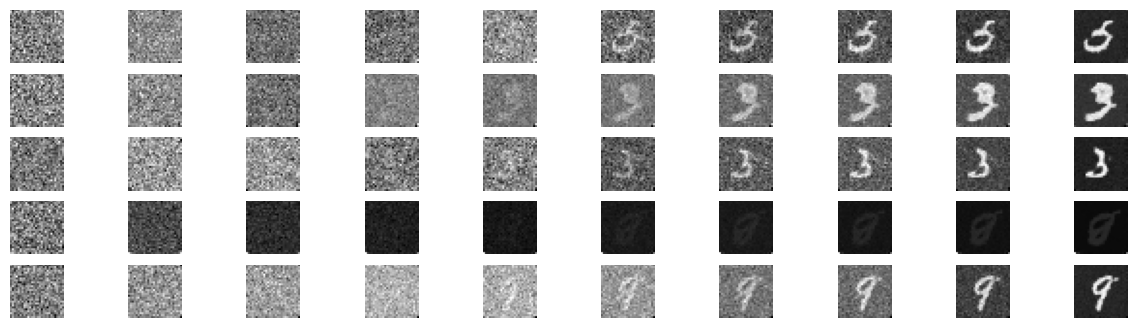

In [9]:
from diffusion_lib.utils.visualization import plot_image_evolution

_ = plot_image_evolution(
    images=synthetic_images_vp_lin.cpu(),
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

2. Using the cosine noise schedule.


In [10]:
from diffusion_lib import UNetScoreModel as ScoreNet
from diffusion_lib import VPProcess, CosineSchedule, EulerMaruyamaSampler, GenerativeDiffusionModel
import torch.optim as optim

vp_process_cos = VPProcess(schedule=CosineSchedule())
score_model_vp_cos = ScoreNet(marginal_prob_std=vp_process_cos.sigma_t).to(device)
gm_vp_cos = GenerativeDiffusionModel(vp_process_cos, EulerMaruyamaSampler(), score_model_vp_cos, device)
optimizer = optim.Adam(score_model_vp_cos.parameters(), lr=1e-3)


In [11]:
''' YOU CAN SKIP THIS CELL SINCE THE MODEL IS ALREADY TRAINED AND THE CHECKPOINTS ARE SAVED IN OTHER_CHECKPOINTS/ '''

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# epochs = 500
# loss_history = []

# score_model_vp_cos.train()

# print(f"Entrenando en {device}...")

# for epoch in range(epochs):
#     epoch_loss = 0
#     for images, _ in train_loader:
#         loss = gm_vp_cos.compute_loss(images)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         epoch_loss += loss.item()

#     avg_loss = epoch_loss / len(train_loader)
#     loss_history.append(avg_loss)
#     print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

# torch.save(score_model_vp_cos.state_dict(), 'other_checkpoints/mnist_vp_cosine_trained.pth')

' YOU CAN SKIP THIS CELL SINCE THE MODEL IS ALREADY TRAINED AND THE CHECKPOINTS ARE SAVED IN OTHER_CHECKPOINTS/ '

In [12]:
checkpoint = torch.load(
    'other_checkpoints/mnist_vp_cosine_trained.pth',
    map_location=device,
    weights_only=True,
)
score_model_vp_cos.load_state_dict(checkpoint)
gm_vp_cos.T = 0.999   

n_images = 5
synthetic_images_vp_cos = gm_vp_cos.sample(
    n_images=n_images,
    img_shape=(1, 28, 28),   
    n_steps=500,
    return_trajectory=True,
)

print(f"Dimensiones finales: {synthetic_images_vp_cos.shape}")

Dimensiones finales: torch.Size([5, 1, 28, 28, 501])


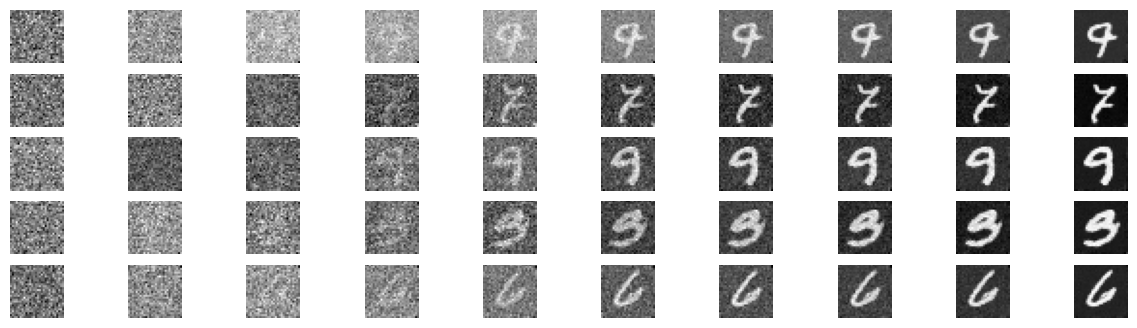

In [13]:
from diffusion_lib.utils.visualization import plot_image_evolution

_ = plot_image_evolution(
    images=synthetic_images_vp_cos.cpu(),
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

3. Using a third noise schedule of your choice.

In [14]:
from diffusion_lib import ExponentialSchedule
vp_process_exp= VPProcess(schedule=ExponentialSchedule())
score_model_vp_exp = ScoreNet(marginal_prob_std=vp_process_exp.sigma_t).to(device)
gm_vp_exp = GenerativeDiffusionModel(vp_process_exp, EulerMaruyamaSampler(), score_model_vp_exp, device)
optimizer = optim.Adam(score_model_vp_exp.parameters(), lr=1e-3)

In [15]:
''' YOU CAN SKIP THIS CELL SINCE THE MODEL IS ALREADY TRAINED AND THE CHECKPOINTS ARE SAVED IN OTHER_CHECKPOINTS/ '''

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# epochs = 500
# loss_history = []

# score_model_vp_exp.train()

# print(f"Entrenando en {device}...")

# for epoch in range(epochs):
#     epoch_loss = 0
#     for images, _ in train_loader:
#         loss = gm_vp_exp.compute_loss(images)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         epoch_loss += loss.item()

#     avg_loss = epoch_loss / len(train_loader)
#     loss_history.append(avg_loss)
#     print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

# torch.save(score_model_vp_exp.state_dict(), 'other_checkpoints/mnist_vp_exponential_trained.pth')

' YOU CAN SKIP THIS CELL SINCE THE MODEL IS ALREADY TRAINED AND THE CHECKPOINTS ARE SAVED IN OTHER_CHECKPOINTS/ '

In [16]:
checkpoint = torch.load(
    'other_checkpoints/mnist_vp_exponential_trained.pth',
    map_location=device,
    weights_only=True,
)
score_model_vp_exp.load_state_dict(checkpoint)

n_images = 5
synthetic_images_vp_exp = gm_vp_exp.sample(
    n_images=n_images,
    img_shape=(1, 28, 28),   
    n_steps=1500,
    return_trajectory=True,
)

print(f"Dimensiones finales: {synthetic_images_vp_exp.shape}")

Dimensiones finales: torch.Size([5, 1, 28, 28, 1501])


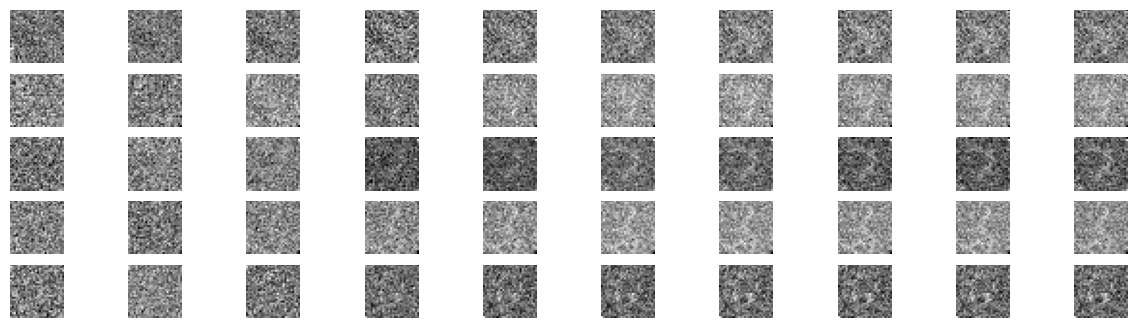

In [17]:
from diffusion_lib.utils.visualization import plot_image_evolution

_ = plot_image_evolution(
    images=synthetic_images_vp_exp.cpu(),
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

## Exercise 3:  Evaluation of the quality of the generated images
1. Describe, and compare the characteristics, advantages, and disadvantages of the following measures of quality for generative IA models for images:
    1. The negative log-likelihood (NLL).
        - **Charateristics**: quantifies the model quality by checking how well it estimates the real probaility density of the data. You measure of a negative log-likelihood of a training subset.
        - **Pros**: The closest metric to the loss function 
        - **Cons**: Low NLL does not imply a good visual quality.
    2. Bits per dimension (BPD). 
        - **Charateristics**: Scaled version of NLL, in order to make the interpretation regardless of the dimension of the images. $ BPD=\frac{NLL}{\mathcal{D}\log2}$.

        - **Pros**: Is a meteric that can be used to compare models in spite of their input dimensions.
        - **Cons**: Since the metric is basically NLL scaled, it inherints its disadvantages.
    3. Fréchet Inception Distance (FID).
        - **Charateristics**: Using a pretrained net, in this case Inception V3, it calculates the Fréchet distance between both distributions.
        - **Pros**: It is nowadays standard because the metric is able to capture both the image percption quality and the diversity in the results.
        - **Cons**: Assumes Gaussian behavour which can be false.
    4. Inception Score.
        - **Charateristics**: Simialr to FID but instead of measuring the perceptual quality measures the clarity of the image.
        - **Pros**: Good tool to check for collapsing models.
        - **Cons**: Not comparing the generations with teh real distribution of the images.
2. Compare using BPD the different diffusion models (Brownian motion, Ornstein-Uhlenbeck), noising schedules (linear, cosine, etc.), and sampling strategies (SDE, ODE) implemented.

> **References:** NLL and BPD as generative model metrics: Theis et al. (2015) [Ref. 7]. Fréchet Inception Distance (FID): Heusel et al. (2017) [Ref. 6]. Inception Score: implicit in Heusel et al. (2017) [Ref. 6]. SVHN dataset: Netzer et al. (2011) [Ref. 11].

VE  Brownian: -1.974 bpd
VP  Linear: -10.203 bpd
VP  Cosine: -10.576 bpd
VP  Exponential: -10.655 bpd


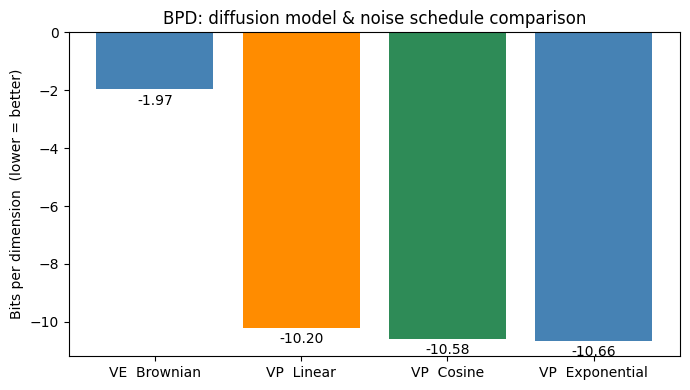

In [18]:
import torch
import matplotlib.pyplot as plt
from diffusion_lib import UNetScoreModel as ScoreNet
from diffusion_lib import (
    VEProcess, VPProcess, LinearSchedule, CosineSchedule, ExponentialSchedule,
    EulerMaruyamaSampler, GenerativeDiffusionModel,
)
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

x_eval, _ = next(iter(
    DataLoader(
        datasets.MNIST(root='./data', train=False, download=True,
                       transform=transforms.ToTensor()),
        batch_size=32, shuffle=False,
    )
))

configs = [
    ('VE  Brownian',  VEProcess(sigma=25.0),               'other_checkpoints/mnist_brownian_trained.pth'),
    ('VP  Linear',   VPProcess(schedule=LinearSchedule()), 'other_checkpoints/mnist_vp_linear_trained.pth'),
    ('VP  Cosine',   VPProcess(schedule=CosineSchedule()), 'other_checkpoints/mnist_vp_cosine_trained.pth'),
    ('VP  Exponential', VPProcess(schedule=ExponentialSchedule()), 'other_checkpoints/mnist_vp_exponential_trained.pth'),
]

bpd_vals, labels = [], []
for name, process, ckpt in configs:
    net = ScoreNet(marginal_prob_std=process.sigma_t)
    net.load_state_dict(torch.load(ckpt, map_location='cpu', weights_only=True))
    gm_eval = GenerativeDiffusionModel(process, EulerMaruyamaSampler(), net, device)
    bpd = gm_eval.compute_bpd(x_eval, n_steps=50, n_hutchinson=1).mean().item()
    bpd_vals.append(bpd)
    labels.append(name)
    print(f'{name}: {bpd:.3f} bpd')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, bpd_vals, color=['steelblue', 'darkorange', 'seagreen'])
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_ylabel('Bits per dimension  (lower = better)')
ax.set_title('BPD: diffusion model & noise schedule comparison')
plt.tight_layout()
plt.show()